In [32]:
from spacerocks import SpaceRock
from spacerocks.time import Time
from spacerocks.observing import Observatory, Observation
from spacerocks.spice import SpiceKernel
from spacerocks.nbody import Simulation, Force
from spacerocks.orbfit import gauss, fit_orbit_lm, orbit_chisq
import numpy as np


import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

kernel = SpiceKernel()
kernel.load("/Users/kjnapier/data/spice/latest_leapseconds.tls")
kernel.load("/Users/kjnapier/data/spice/sb441-n16.bsp")
kernel.load("/Users/kjnapier/data/spice/de441_part-1.bsp")
kernel.load("/Users/kjnapier/data/spice/de441_part-2.bsp")
kernel.load("/Users/kjnapier/data/spice/earth_1962_240827_2124_combined.bpc")

Loading kernel: /Users/kjnapier/data/spice/latest_leapseconds.tls
Loading kernel: /Users/kjnapier/data/spice/sb441-n16.bsp
Loading kernel: /Users/kjnapier/data/spice/de441_part-1.bsp
Loading kernel: /Users/kjnapier/data/spice/de441_part-2.bsp
Loading kernel: /Users/kjnapier/data/spice/earth_1962_240827_2124_combined.bpc


In [33]:
w84 = Observatory.from_obscode('w84')

In [72]:
epoch = Time.now()

name = "holman"
rock = SpaceRock.from_horizons(name, epoch=epoch, origin="ssb", reference_plane="J2000")
sim = Simulation.horizons(epoch, "J2000", "ssb")
sim.add(rock)

In [73]:
observations = []    
for idx in range(0, 300, 10):
    sim.integrate(epoch + idx)
    observer = w84.at(epoch + idx, reference_plane="J2000", origin="ssb")
    rock = sim.get_particle(name)
    obs = rock.observe(observer)
    observations.append(obs)

In [74]:
smear = 0.1/3600 * (np.pi / 180)

In [80]:
simulated_observations = []
for obs in observations:
    ra = obs.ra
    dec = obs.dec
    ra += np.random.normal(0, smear)
    dec += np.random.normal(0, smear)
    epoch = obs.epoch
    observer = obs.observer
    cov = [[smear**2, 0], [0, smear**2]]
    simulated_o = Observation.from_astrometry(obs.epoch, ra, dec, obs.observer)
    simulated_o.set_covariance(cov)
    simulated_observations.append(simulated_o)

In [81]:
import itertools

In [82]:
len(simulated_observations)

# generate all possible triplets of observations
triplets = list(itertools.combinations(simulated_observations, 3))

In [91]:
%%time
eccentricities = []
dts = []
ratios = []
for triplet in triplets:
    rocks = gauss(triplet[0], triplet[1], triplet[2], min_distance=1.0)
    times = [obs.epoch.tdb().jd() for obs in triplet]
    # sort the times
    times.sort()
    dt1 = times[1] - times[0]
    dt2 = times[2] - times[1]
    dt = times[2] - times[0]
    if rocks is None:
        continue
    for rock in rocks:
        eccentricities.append(rock.e())
        dts.append(dt)
        ratio = min(dt1, dt2) / max(dt1, dt2)
        ratios.append(ratio)

eccentricities = np.array(eccentricities)
keep = eccentricities < 1.0
eccentricities = eccentricities[keep]
dts = np.array(dts)
dts = dts[keep]
ratios = np.array(ratios)
ratios = ratios[keep]


CPU times: user 34.7 ms, sys: 3.62 ms, total: 38.3 ms
Wall time: 55.5 ms


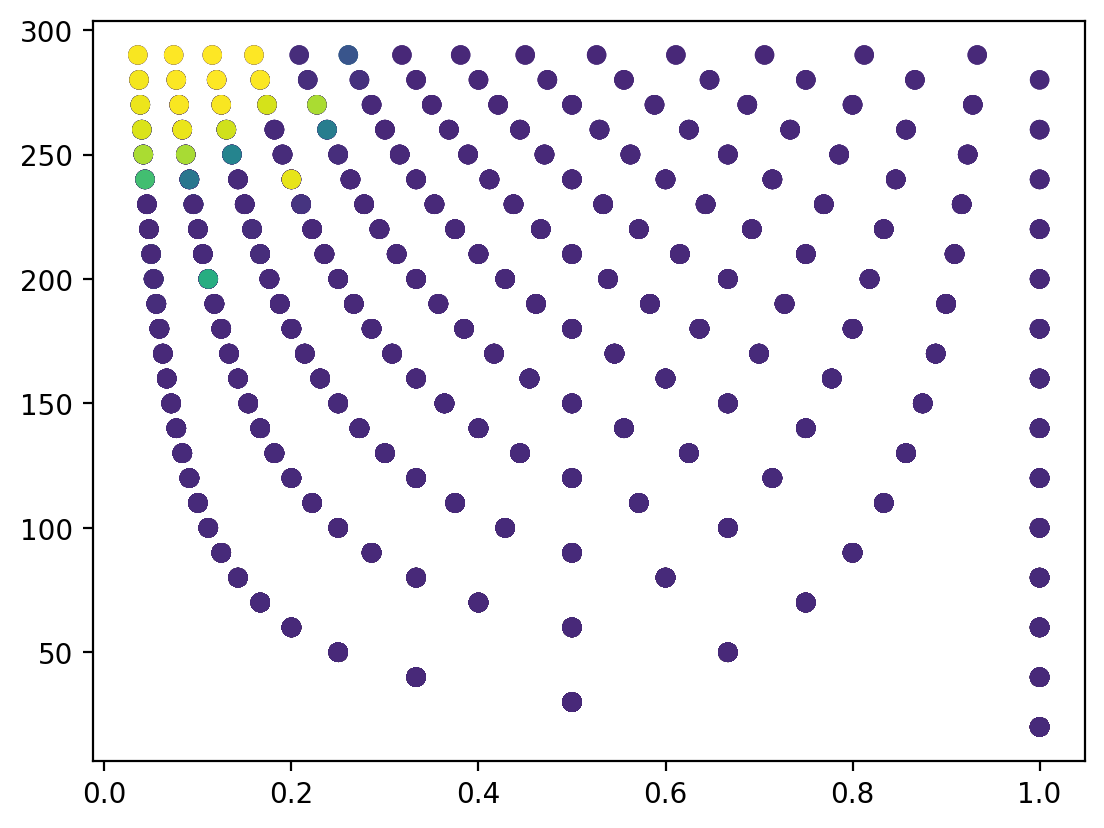

In [92]:
plt.scatter(ratios, dts, c=eccentricities, cmap='viridis')

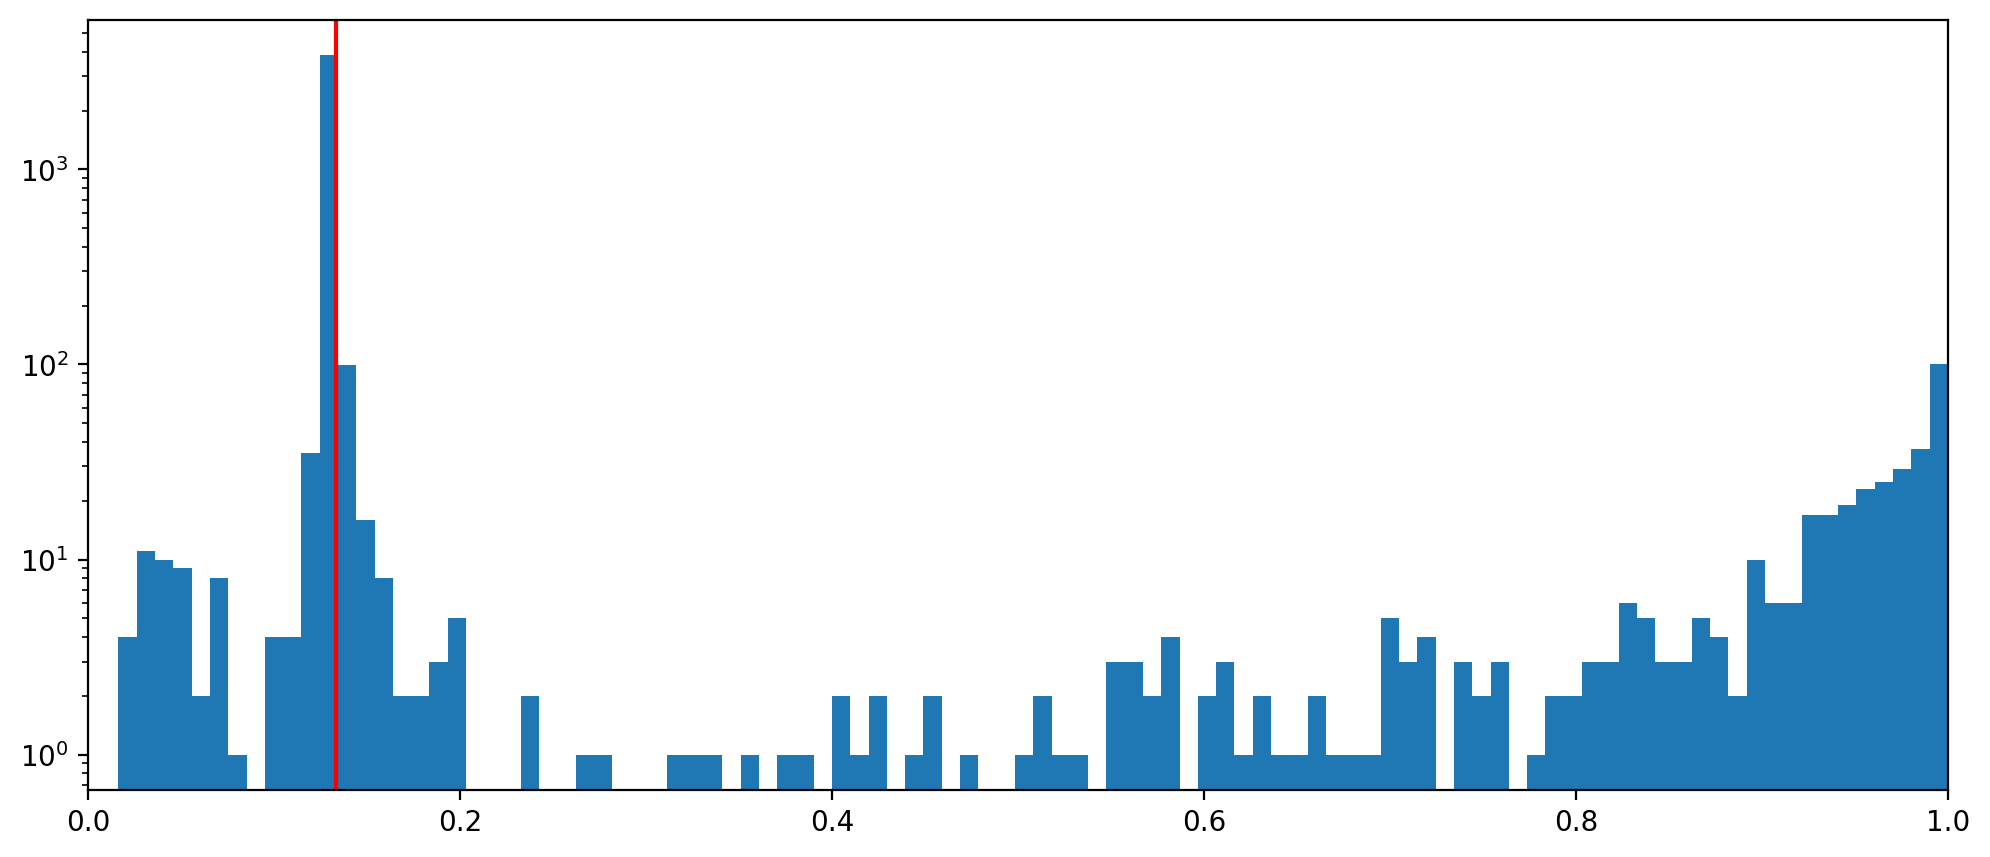

In [84]:
fig, ax = plt.subplots(figsize=(12, 5))
_ = ax.hist(eccentricities, bins=100)
ax.set_yscale('log')
ax.set_xlim([0, 1])
ax.axvline(rock.e(), color='red')
#ax.set_xscale('log')

In [23]:
%%timeit
rocks = gauss(simulated_observations[0], simulated_observations[5], simulated_observations[9], min_distance=1e-6)


6.37 μs ± 37.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
sim = Simulation.giants(rocks[0].epoch, "J2000", "ssb")
fit_orbit_lm(simulated_observations, rocks[0], sim)

In [8]:
orbit_chisq(simulated_observations, rocks[0], sim)

17159.122089376182